Shape: (119390, 32)
Duplicates: 31994

Missing Values:
company                   82137
agent                     12193
country                     452
children                      4
reserved_room_type            0
assigned_room_type            0
booking_changes               0
deposit_type                  0
hotel                         0
previous_cancellations        0
dtype: int64

Overall Cancellation Rate: 27.49 %

Cancellation by Hotel:
hotel
City Hotel      30.038557
Resort Hotel    23.480923
Name: is_canceled, dtype: float64


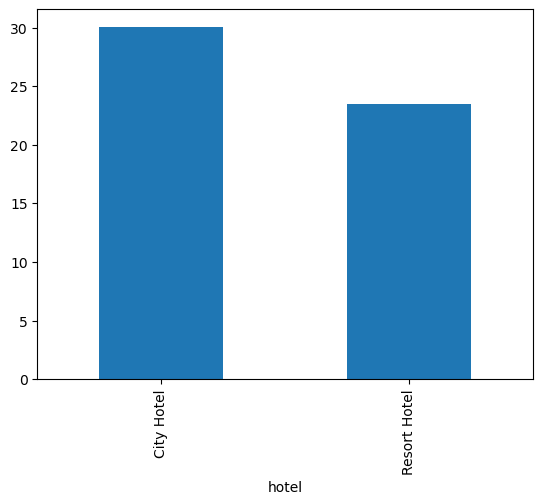


Hotel Distribution:
hotel
City Hotel      53428
Resort Hotel    33968
Name: count, dtype: int64


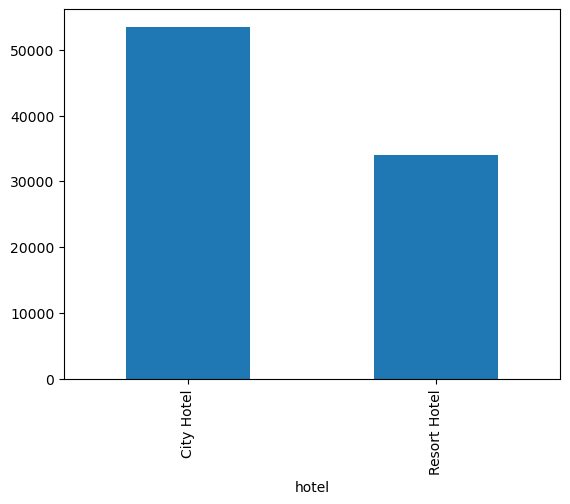


Bookings by Month:
arrival_date_month
January       4693
February      6098
March         7513
April         7908
May           8355
June          7765
July         10057
August       11257
September     6690
October       6934
November      4995
December      5131
Name: count, dtype: int64


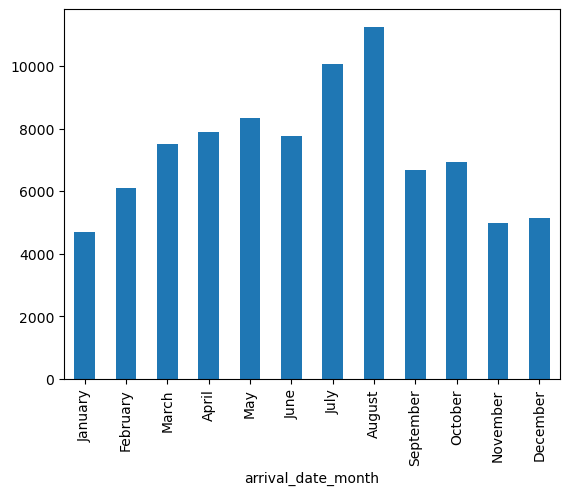


Customer Types:
customer_type
Transient          71986
Transient-Party    11727
Contract            3139
Group                544
Name: count, dtype: int64


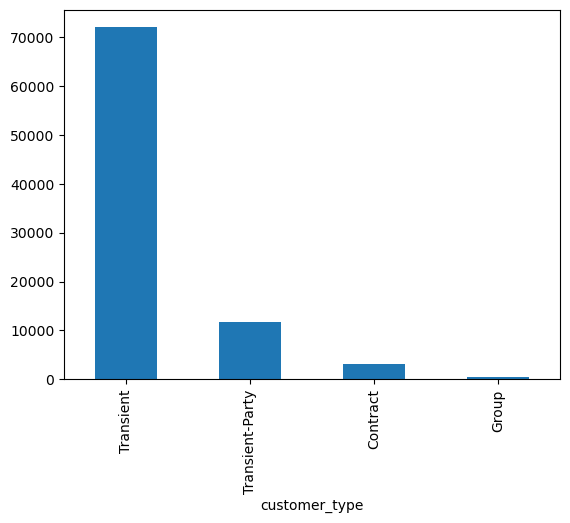


Market Segments:
market_segment
Online TA        51618
Offline TA/TO    13889
Direct           11804
Groups            4942
Corporate         4212
Complementary      702
Aviation           227
Undefined            2
Name: count, dtype: int64


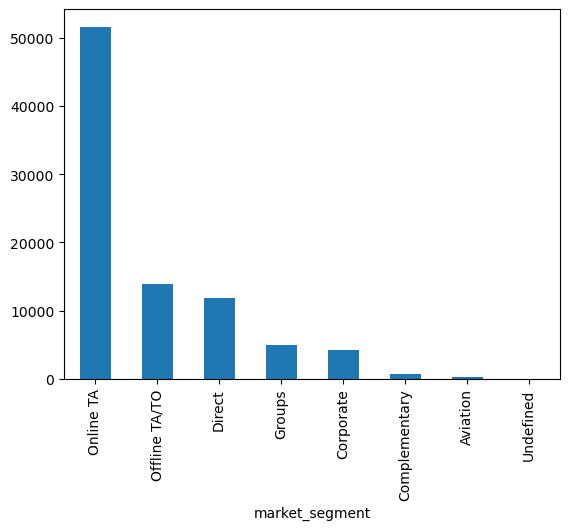


Average ADR: 106.34
Average Lead Time: 79.89


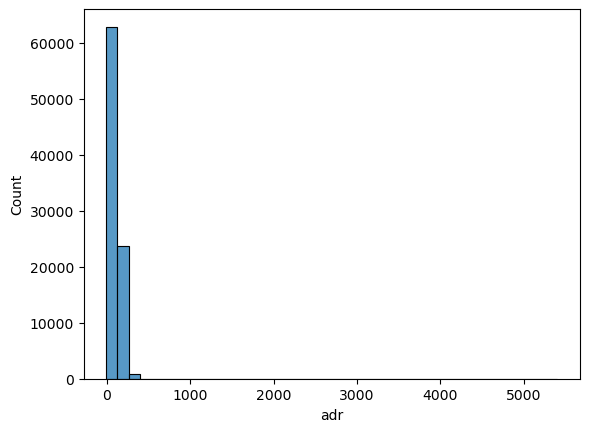

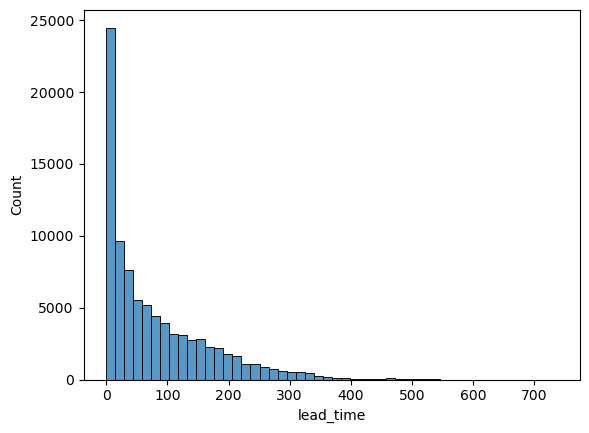

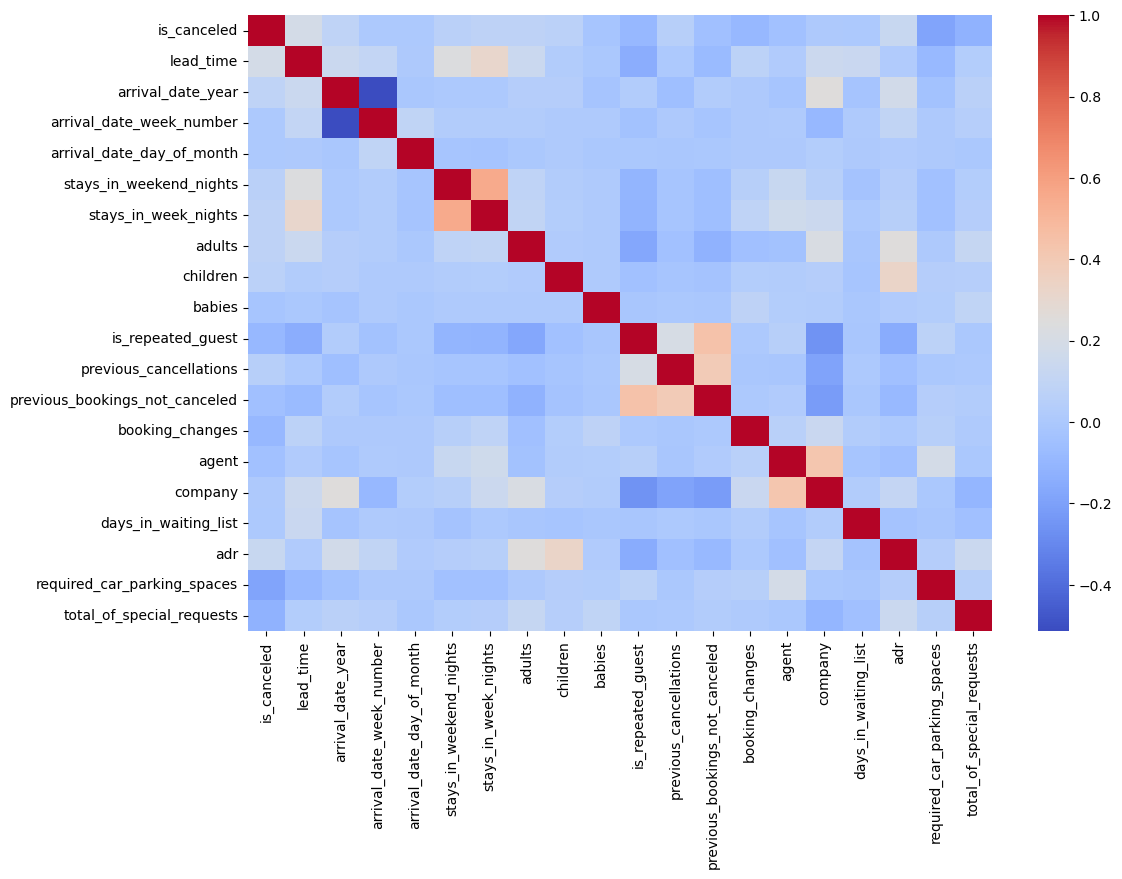

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("hotel_bookings.csv")

print("Shape:", df.shape)

print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

cancel_rate = df['is_canceled'].mean() * 100
print("\nOverall Cancellation Rate:", round(cancel_rate, 2), "%")

hotel_cancel = df.groupby('hotel')['is_canceled'].mean() * 100
print("\nCancellation by Hotel:")
print(hotel_cancel)

hotel_cancel.plot(kind='bar')
plt.show()

hotel_counts = df['hotel'].value_counts()
print("\nHotel Distribution:")
print(hotel_counts)

hotel_counts.plot(kind='bar')
plt.show()

month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

monthly_bookings = df['arrival_date_month'].value_counts()
monthly_bookings = monthly_bookings.reindex(month_order)

print("\nBookings by Month:")
print(monthly_bookings)

monthly_bookings.plot(kind='bar')
plt.show()

customer = df['customer_type'].value_counts()
print("\nCustomer Types:")
print(customer)

customer.plot(kind='bar')
plt.show()

market = df['market_segment'].value_counts()
print("\nMarket Segments:")
print(market)

market.plot(kind='bar')
plt.show()

print("\nAverage ADR:", round(df['adr'].mean(), 2))
print("Average Lead Time:", round(df['lead_time'].mean(), 2))

sns.histplot(df['adr'], bins=40)
plt.show()

sns.histplot(df['lead_time'], bins=50)
plt.show()

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.show()